In [69]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.pyplot import *
from scipy import stats as st
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
from scipy import optimize as op
from scipy.special import erf
from scipy.optimize import fsolve
from matplotlib.patches import ConnectionPatch
from mpl_toolkits.axes_grid1 import host_subplot
from mpl_toolkits import axisartist
import datetime


In [71]:
#donnees numériques
MT=5.9736e24
ML=7.3477e22
RT=6400e3
RL=1735e3
D=385000e3
Cste_G=6.67e-11
#unités
periode=2*np.pi/np.sqrt(Cste_G*(MT+ML))*(np.sqrt(D))**3
vitesse=np.sqrt(Cste_G*(MT+ML)/D)


alpha=ML/(ML+MT) # paramètre du problème à 2 corps
rT=RT/D #rayon de la terre en unités naturelles
rL=RL/D #rayon de la lune en unités naturelles


#premières vitesses cosmiques de la Terre et la Lune en unités naturelles, et périodes associées
v1T=np.sqrt((1-alpha)/rT)
v1L=np.sqrt(alpha/rL)
periodeT=2*np.pi*rT/v1T
periodeL=2*np.pi*rL/v1L


def rhs(x,t):
    """ force vectorialisée"""
    G1x=-(1-alpha)*(x[0]+alpha)/((x[0]+alpha)**2+x[1]**2)**(3/2)
    G1y=-(1-alpha)*x[1]/((x[0]+alpha)**2+x[1]**2)**(3/2)
    G2x=-alpha*(x[0]-1+alpha)/((x[0]-1+alpha)**2+x[1]**2)**(3/2)
    G2y=-alpha*x[1]/((x[0]-1+alpha)**2+x[1]**2)**(3/2)
    Ficx=2*x[3]
    Ficy=-2*x[2]
    Fiex=x[0]
    Fiey=x[1]
    return  np.array([x[2],x[3],G1x+G2x+Fiex+Ficx,G1y+G2y+Fiey+Ficy])

def rhs2(t,x):
    """ force vectorialisée"""
    G1x=-(1-alpha)*(x[0]+alpha)/((x[0]+alpha)**2+x[1]**2)**(3/2)
    G1y=-(1-alpha)*x[1]/((x[0]+alpha)**2+x[1]**2)**(3/2)
    G2x=-alpha*(x[0]-1+alpha)/((x[0]-1+alpha)**2+x[1]**2)**(3/2)
    G2y=-alpha*x[1]/((x[0]-1+alpha)**2+x[1]**2)**(3/2)
    Ficx=2*x[3]
    Ficy=-2*x[2]
    Fiex=x[0]
    Fiey=x[1]
    return  np.array([x[2],x[3],G1x+G2x+Fiex+Ficx,G1y+G2y+Fiey+Ficy])

def rhs3(t,x):
    """ force vectorialisée"""
    G1x=-(1-alpha)*(x[0]+alpha)/((x[0]+alpha)**2+x[1]**2)**(3/2)
    G1y=-(1-alpha)*x[1]/((x[0]+alpha)**2+x[1]**2)**(3/2)
    G2x=-alpha*(x[0]-1+alpha)/((x[0]-1+alpha)**2+x[1]**2)**(3/2)
    G2y=-alpha*x[1]/((x[0]-1+alpha)**2+x[1]**2)**(3/2)
    Ficx=2*x[3]
    Ficy=-2*x[2]
    Fiex=x[0]
    Fiey=x[1]
    return  np.array([x[2],x[3],G1x+G2x+Fiex+Ficx,G1y+G2y+Fiey+Ficy])


def U(x,y):
    """ énergie potentielle"""
    U1=-(1-alpha)/((x+alpha)**2+y**2)**(1/2)
    U2=-alpha/((x-1+alpha)**2+y**2)**(1/2)
    Ue=-.5*(x**2+y**2)
    return U1+U2+Ue

def f1(u):
    return alpha-u+(1-alpha)/u**2-alpha/(u-1)**2

def f2(u):
    return alpha-u+(1-alpha)/u**2+alpha/(u-1)**2

def f3(u):
    return alpha-u-(1-alpha)/u**2-alpha/(u-1)**2

print("alpha="+str(alpha))
periode/86400
vitesse

alpha=0.012150829235347922


1023.5411359017853

(-10.0, 10.0)

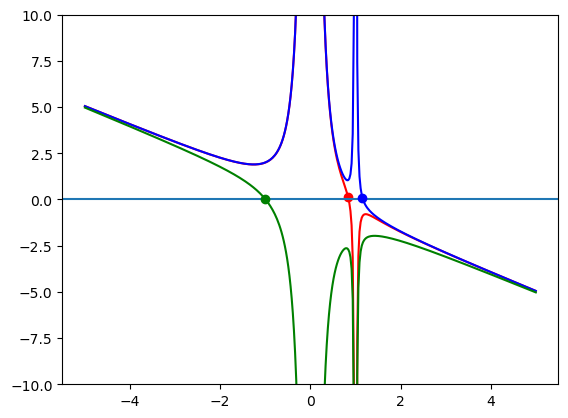

In [73]:
# points de lagrange
u=np.linspace(-5,5,400)
L1=fsolve(lambda x: f1(x),0.1)
L2=fsolve(lambda x: f2(x),10)
L3=fsolve(lambda x: f3(x),-2)
L1-=alpha;L2-=alpha;L3-=alpha;


plot(u,f1(u),'r-');plot(L1,f1(L1),'or');axhline(0)
plot(u,f2(u),'b-');plot(L2,f2(L2),'ob')
plot(u,f3(u),'g-');plot(L3,f3(L3),'og')
ylim([-10,10])


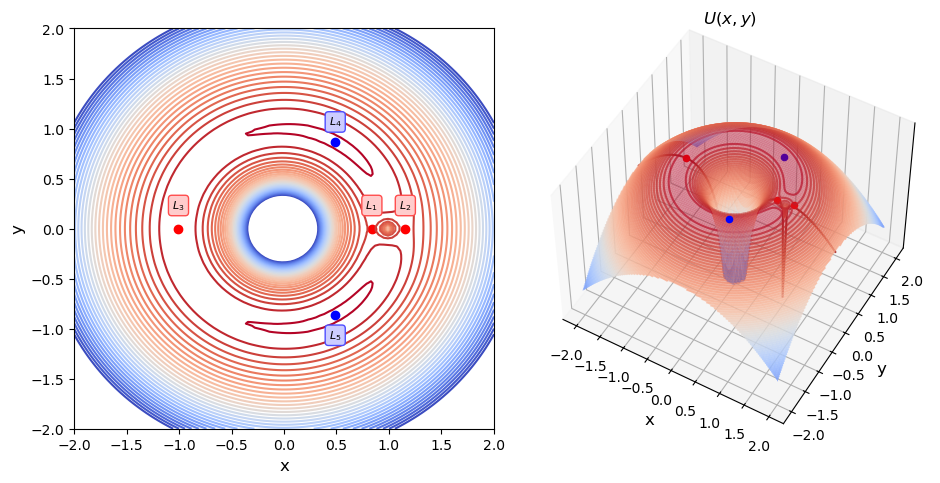

In [75]:
xx=np.linspace(-2,2,100)
yy=np.linspace(-2,2,100)
x,y=np.meshgrid(xx,yy)

taille_graphe=1.57*2
espace_entre_graphes=.28
hauteur=taille_graphe
largeur=taille_graphe*(3+1*espace_entre_graphes)

fig=figure(figsize=figaspect(.5))
graphe1=fig.add_subplot(121)
graphe1.plot(L1,0,'or')
graphe1.plot(L2,0,'or')
graphe1.plot(L3,0,'or')
graphe1.plot(.5-alpha,np.sqrt(3)/2,'ob') #L4
graphe1.plot(.5-alpha,-np.sqrt(3)/2,'ob') #L5
graphe1.text(L1,0.2,"$L_1$ ",size=8,bbox=dict(boxstyle="round",ec=(1., 0.3, 0.3),fc=(1., 0.8, 0.8)),ha='center')
graphe1.text(L2,0.2,"$L_2$ ",size=8,bbox=dict(boxstyle="round",ec=(1., 0.3, 0.3),fc=(1., 0.8, 0.8)),ha='center')
graphe1.text(L3,0.2,"$L_3$ ",size=8,bbox=dict(boxstyle="round",ec=(1., 0.3, 0.3),fc=(1., 0.8, 0.8)),ha='center')
graphe1.set_xlabel("x",size=12)
graphe1.set_ylabel("y",size=12)
graphe1.text(.5-alpha,np.sqrt(3)/2+.2,"$L_4$ ",size=8,bbox=dict(boxstyle="round",ec=(0.3, 0.3,1),fc=(.8, 0.8, 1)),ha='center',va='center')
graphe1.text(.5-alpha,-np.sqrt(3)/2-.2,"$L_5$ ",size=8,bbox=dict(boxstyle="round",ec=(0.3, 0.3,1),fc=(.8, 0.8, 1)),ha='center',va='center')
#graphe1.text(L5,0.2,"$L_5$ ",size=8,bbox=dict(boxstyle="round",ec=(1., 0.3, 0.3),fc=(1., 0.8, 0.8)),ha='center')
graphe1=contour(x,y,U(x,y),levels=np.linspace(-3,-1.5,30),cmap='coolwarm')



#graphe1.axes.get_xaxis().set_ticks([])
#graphe1.axes.get_yaxis().set_ticks([])


graphe2=fig.add_subplot(122,projection='3d')
z=U(x,y)

U0=U(xx,0)
limite=-5
U0[U0<limite]=limite
z[z<limite]=limite

graphe2.plot_surface(x,y,z,cmap='coolwarm',rstride=1,cstride=1,alpha=.5)
graphe2.contour(x,y,z,cmap='coolwarm',levels=np.linspace(limite,np.max(z),80),alpha=.7)
graphe2.plot(xx,0*xx,U0,color='brown',lw='1.5',ls='-')
graphe2.scatter([L1],[0],[U(L1,0)],color='red')
graphe2.scatter([L2],[0],[U(L3,0)],color='red')
graphe2.scatter([L3],[0],[U(L3,0)],color='red')
graphe2.scatter([.5-alpha],[np.sqrt(3)/2],[U(.5-alpha,np.sqrt(3)/2)],color='blue')
graphe2.scatter([.5-alpha],[-np.sqrt(3)/2-.2],[U(.5-alpha,-np.sqrt(3)/2)+.4],color='blue')



graphe2.view_init(elev=50, azim=-60, roll=0)
graphe2.set_xlabel("x",size=12)
graphe2.set_ylabel("y",size=12)


graphe2.set_title("$U(x,y)$", fontsize=12,pad=0,loc='center')
graphe2.axes.get_zaxis().set_ticks([])

np.max(z),np.min(z)
fig.tight_layout()
#savefig("pts_lagrange_TL.pdf",format='pdf')


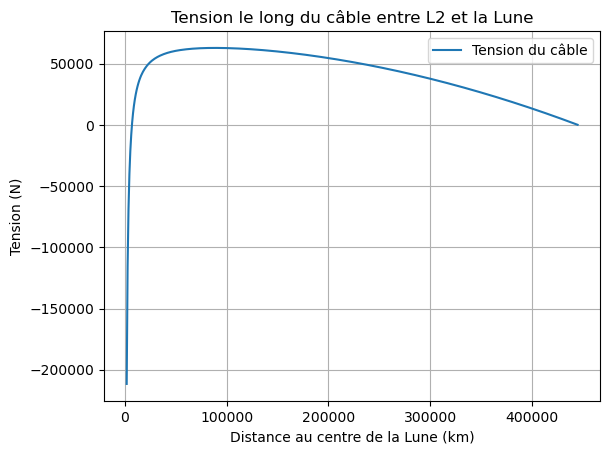

In [77]:
rho = 1000  # Densité linéique du câble en kg/m (exemple)
A = 1e-4    # Section constante du câble en m² (exemple)
omega = np.sqrt(Cste_G * (MT + ML) / D**3) # vitesse angulaire
# Gravité effective
def g_eff(r):
    g_lune = Cste_G * ML / r**2
    f_centrifuge = omega **2 * r
    return g_lune - f_centrifuge

# Équation différentielle de la tension
def tension_eq(r, T):
    return rho * A * g_eff(r)

# Résolution de l'équation de la tension avec une condition initiale
# Début du câble au point L2, jusqu'à la surface de la Lune
r_L2 = 1.15568 * D  # Distance de L2 à la Lune (exemple)
r_lune = 1735e3     # Rayon de la Lune
T_init = 0          # Condition initiale : tension au point L2 (supposée nulle ici)

# Résolution de l'ODE
solution = solve_ivp(tension_eq, [r_L2, r_lune], [T_init], method='RK45', dense_output=True)

# Tracé de la tension en fonction de la distance au centre de la Lune
r_vals = np.linspace(r_L2, r_lune, 500)
T_vals = solution.sol(r_vals).T[:, 0]

plt.figsize=(10, 6)
plt.plot(r_vals / 1e3, T_vals, label='Tension du câble')
plt.xlabel("Distance au centre de la Lune (km)")
plt.ylabel("Tension (N)")
plt.title("Tension le long du câble entre L2 et la Lune")
plt.legend()
plt.grid()
plt.show()

In [93]:
TMAX=2#10*periodeT
N=1000000
t=np.linspace(0.,TMAX,N)# on laisse évoluer 
tt=t/(2*np.pi)



theta0=-np.pi*.65

r0=rT*1.2
v0=v1T*np.sqrt(rT/r0)*np.sqrt(2)*.9887

x0,y0=-alpha+r0*np.cos(theta0),r0*np.sin(theta0)
vx0,vy0=-v0*np.sin(theta0),v0*np.cos(theta0)

CI=[x0,y0,vx0,vy0]
traj=odeint(rhs,CI,t)
print(((traj[0][0]+1-alpha)**2 + traj[0][1]**2)**0.5)
traj=odeint(rhs,CI,t)

0.9668055072868634


In [95]:
def distance_Min_Lune(traj):
    tMin,dMin=0,((-traj[0][0]+1-alpha)**2 + traj[0][1]**2)**0.5
    for i in range(len(traj)):
        d = ((-traj[i][0]+1-alpha)**2 + traj[i][1]**2)**0.5
        if d <= dMin : 
            dMin= d
            tMin=i
    return tMin,dMin,traj[tMin][3]

t_racc = distance_Min_Lune(traj)[0]

In [120]:
import numpy as np
from scipy.integrate import solve_ivp



# Fonctions d'événements
def distance_satelisation(t, x):
    return np.sqrt((-x[0] + 1 - alpha)**2 + x[1]**2) - (10 * RL / D)

def est_dans_la_lune(t, x):
    return np.sqrt((-x[0] + 1 - alpha)**2 + x[1]**2) - (RL / D)

# Configuration des événements
distance_satelisation.terminal = False
distance_satelisation.direction = 0
est_dans_la_lune.terminal = True

# Paramètres de simulation
nombre_essaie = 30
valeur_theta0 = np.linspace(1.5, np.pi * 0.75, nombre_essaie)
TMAX = 2.5
N = 1000  # Nombre total de points souhaités

# Variables pour stocker les résultats
val_x = []
val_t = []
deltaV = []
distance_satelisation_atteint = []

for k in range(nombre_essaie):
    theta0 = -valeur_theta0[k]
    r0 = rT * 1.2
    v0 = v1T * np.sqrt(rT / r0) * np.sqrt(2) * 0.9887
    deltaV.append(v0)

    # Conditions initiales
    x0 = -alpha + r0 * np.cos(theta0)
    y0 = r0 * np.sin(theta0)
    vx0 = -v0 * np.sin(theta0)
    vy0 = v0 * np.cos(theta0)
    CI = [x0, y0, vx0, vy0]

    # Variables pour stocker les résultats partiels
    valeur_x = []
    valeur_t = []
    temps_event = []
    t_start = 0
    point_utilise = 0
    trajectoire_initiale_x = []
    trajectoire_initiale_t = []

    while t_start < TMAX and point_utilise < N:
        remaining_points = N - point_utilise
        t_eval = np.linspace(t_start, TMAX, remaining_points)

        traj2 = solve_ivp(rhs2, (t_start, TMAX), CI, method='RK45', t_eval=t_eval,
                          rtol=1.49012e-12, atol=1.49012e-12,
                          events=[distance_satelisation, est_dans_la_lune],
                          dense_output=True)

        valeur_x.append(traj2.y)
        valeur_t.append(traj2.t)
        point_utilise += len(traj2.t)

        if traj2.t_events[0].size > 0:
            temps_event.extend(traj2.t_events[0])
            t_start = traj2.t_events[0][-1]
            CI = traj2.sol(t_start).ravel()

        if len(temps_event) == 2:
            trajectoire_initiale_x = np.hstack(valeur_x)
            trajectoire_initiale_t = np.hstack(valeur_t)

            distances = np.sqrt((trajectoire_initiale_x[0, :] - (1 - alpha))**2 +
                                trajectoire_initiale_x[1, :]**2)
            n = np.argmin(distances)
            dMin = distances[n]

            x_min = trajectoire_initiale_x[0, n]
            y_min = trajectoire_initiale_x[1, n]
            vx_min = trajectoire_initiale_x[2, n]
            vy_min = trajectoire_initiale_x[3, n]
            normeV = np.sqrt(alpha / dMin)

            deltaV[k] += abs(np.sqrt(vx_min**2 + vy_min**2) - normeV)

            angle_lune_fusee = np.arctan2(y_min, x_min - (1 - alpha))
            vx_circ = -np.sin(angle_lune_fusee) * normeV
            vy_circ = np.cos(angle_lune_fusee) * normeV

            t_start = trajectoire_initiale_t[n]
            CI = [x_min, y_min, vx_circ, vy_circ]

            valeur_x = []
            valeur_t = []

            remaining_points = N - n
            t_eval = np.linspace(t_start, TMAX, remaining_points)
            traj2 = solve_ivp(rhs2, (t_start, TMAX), CI, method='DOP853',
                              max_step=1e-3, t_eval=t_eval,
                              rtol=1.49012e-12, atol=1.49012e-12,
                              events=[distance_satelisation, est_dans_la_lune],
                              dense_output=True)

            valeur_x.append(traj2.y)
            valeur_t.append(traj2.t)
            valeur_x = np.hstack(valeur_x)
            valeur_t = np.hstack(valeur_t)
            valeur_x = np.hstack([trajectoire_initiale_x[:n], valeur_x])
            valeur_t = np.hstack([trajectoire_initiale_t[:n], valeur_t])
            break

    

    val_x.append(valeur_x)
    val_t.append(valeur_t)
    distance_satelisation_atteint.append(len(temps_event) > 0)

deltaVmin = min(deltaV)
index_deltaVmin = deltaV.index(deltaVmin)
print(deltaVmin, index_deltaVmin)






9.839535717166854 0


In [121]:
def raccord_traj(CI_perturbation,traj): ## t_racc est un indice et non un temps, déso pas déso
    # Trouver l'indice t_racc avec votre condition événementielle
    t_racc_index = distance_Min_Lune(traj)[0]  # Assurez-vous que ça retourne un index
    t_racc_time = t[t_racc_index]              # Récupérer le temps correspondant

    # Définir l'intervalle de temps pour la nouvelle intégration
    t2 = np.linspace(t_racc_time, TMAX, N - t_racc_index)  # Ajusté pour la continuité temporelle

    CI_racc= traj[t_racc]+CI_perturbation
    CI_racc=[round(CI_racc[0],4),round(CI_racc[1],8),round(CI_racc[2],3),round(CI_racc[3],3)]
    print(CI_racc)
    traj_racc=traj
    traj_racc[t_racc:]=odeint(rhs,CI_racc,t2)[:N-t_racc]
    #traj_racc[round(1.1*t_racc):]=traj_racc[round(1.1*t_racc)]
    return traj_racc

    
CI_perturbation=[0,0,0,+0.6]
traj_racc=raccord_traj(CI_perturbation, traj)
tMin=0

ValueError: Number of samples, -510390, must be non-negative.

In [126]:
def CI_orbite_circulaire(x_min,y_min,vx_min,vy_min):
    d= ((-x_min+1-alpha)**2 + y_min**2)**0.5
    normeV= - alpha / d
    deltaV = abs((vx_min**2 + vy_min**2)**0.5 - normeV)
    print((1-x_min-alpha)/d)
    angle_lune_fusee= np.arccos((1-x_min-alpha)/d)
    vx_circ, vy_circ = np.sin(angle_lune_fusee) * normeV , np.cos(angle_lune_fusee) * normeV
    return [x_min, y_min, vx_circ, vy_circ], deltaV
CI_circ = CI_orbite_circulaire(traj[tMin][0],traj[tMin][1],traj[tMin][2],-traj[tMin][3])[0]
CI_circ=[round(CI_circ[0],3),round(CI_circ[1],3),round(CI_circ[2],2),round(CI_circ[3],2)]
print(CI_circ)
def raccord_traj2(CI_circ,traj): ## t_racc est un indice et non un temps, déso pas déso
    # Trouver l'indice t_racc avec votre condition événementielle
    t_racc_index = t_racc  # Assurez-vous que ça retourne un index
    t_racc_time = t[t_racc_index]              # Récupérer le temps correspondant

    # Définir l'intervalle de temps pour la nouvelle intégration
    t2 = np.linspace(t_racc_time, TMAX, N - t_racc_index)  # Ajusté pour la continuité temporelle
    traj_racc=traj
    traj_racc[t_racc:]=odeint(rhs,CI_circ,t2)[:N-t_racc]
    #traj_racc[round(1.1*t_racc):]=traj_racc[round(1.1*t_racc)]
    return traj_racc

traj_racc=raccord_traj2(CI_circ, traj)[0]


0.9998449038649604
[-0.021, -0.018, -0.0, -0.01]


ValueError: Number of samples, -510390, must be non-negative.

In [128]:
print(valeur_theta0[-2])
print(np.cos(angle_lune_fusee))
print(vx_circ, vy_circ)

2.3266705422546776
-0.6734168276035799
0.45034186596264575 -0.4102299081915552


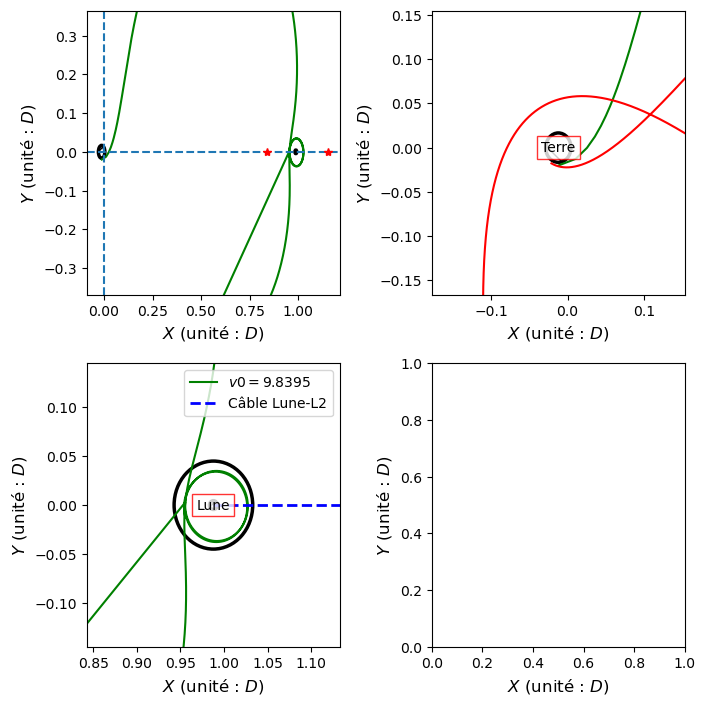

In [130]:
#t_racc=distance_Min_Lune(traj)[0]

taille_graphe=1.57*2.
espace_entre_graphes=.28
hauteur=taille_graphe*(2+1*espace_entre_graphes)
largeur=taille_graphe*(2+1*espace_entre_graphes)

fig=figure(figsize=(largeur,hauteur))
graphe1=fig.add_subplot(221)
graphe2=fig.add_subplot(222)
graphe3=fig.add_subplot(223)#,projection='polar')
graphe4=fig.add_subplot(224)

dist_max=10


xmax=np.max(traj[:,0]);xmin=np.min(traj[:,0]);xmoy=(xmin+xmax)/2;dx=(xmax-xmin)/2
ymax=np.max(traj[:,1]);ymin=np.min(traj[:,1]);ymoy=(ymin+ymax)/2;dy=(ymax-ymin)/2
beta=1.2
XM=xmoy+dx*beta;Xm=xmoy-dx*beta
Ym=ymoy-dy*beta;YM=ymoy+dy*beta

graphe3.plot(val_x[1][0],val_x[1][1],'g-',label='$v0=${:.4f}'.format(v0))
graphe2.plot(val_x[1][0],val_x[1][1],'g-',label='$v0=${:.4f}'.format(v0))
graphe1.plot(val_x[1][0],val_x[1][1],'g-',label='$v0=${:.4f}'.format(v0))




#graphe1.plot(traj[:,0],traj[:,1],'r-',label='$v0=${:.4f}'.format(v0))
#graphe1.plot(traj_racc[:,0],traj_racc[:,1],'b-',label='$v0=${:.4f}'.format(v0))
graphe1.axhline(0,ls='--');graphe1.axvline(0,ls='--')
graphe1.set_ylim([ymin-.05*dy,ymax+.05*dy])

graphe1.add_patch(Circle((-alpha,0),RT/D,edgecolor= 'black',fill=False,hatch='//',lw=2.5))
graphe1.add_patch(Circle((1-alpha,0),RL/D,edgecolor= 'black',fill=False,hatch='//',lw=2.5))
graphe1.plot([L1],[0],'r*')
graphe1.plot([L2],[0],'r*')

#graphe3.plot(traj[:,0],traj[:,1],'r-',label='$v0=${:.4f}'.format(v0))
#graphe3.plot(traj_racc[:,0],traj_racc[:,1],'-',label='$v0=${:.4f}'.format(v0))


graphe3.set_xlim([(1-alpha-dist_max*rL)-0.1,(1-alpha+dist_max*rL)+0.1])
graphe3.set_ylim([(-dist_max*rL)-0.1,(dist_max*rL)+0.1])
graphe3.add_patch(Circle((1-alpha,0),RL/D,edgecolor= 'black',fill=False,hatch='//',lw=2.5))
graphe3.add_patch(Circle((1-alpha,0),10*RL/D,edgecolor= 'black',fill=False,lw=2.5))




graphe2.plot(traj[:,0],traj[:,1],'r-',label='$v0=${:.4f}'.format(v0))

graphe2.set_xlim([-alpha-dist_max*rT,-alpha+dist_max*rT])
graphe2.set_ylim([-dist_max*rT,-alpha+dist_max*rT])
graphe2.add_patch(Circle((-alpha,0),RT/D,edgecolor= 'black',fill=False,hatch='\\',lw=2.5))
#graphe4.add_patch(Circle((0,0),1+h0,edgecolor='black',fill=False,lw=.5))

#graphe4.plot([L3],[0],[U(L3,0)],color='red')


graphe2.text(-alpha,0,'Terre',ha='center',va='center',bbox=dict(boxstyle="square",ec='red',fc='white',alpha=.8))
graphe3.text(1-alpha,0,'Lune',ha='center',va='center',bbox=dict(boxstyle="square",ec='red',fc='white',alpha=.8))

# Ajouter le câble entre la Lune et le point L2 dans le graphique 3
cable_x = [1 - alpha, L2[0]]  # Coordonnées x : de la Lune à L2
cable_y = [0, 0]           # Coordonnées y : les deux points sont sur l'axe des x

# Tracé du câble dans graphe3
graphe3.plot(cable_x, cable_y, 'b--', linewidth=2, label="Câble Lune-L2")  # Ligne bleue en pointillé pour le câble
graphe3.legend()

for ax in fig.axes:
    #ax.legend(loc=3)
    ax.set_xlabel('$X$ (unité : $D$)',fontsize=12)
    ax.set_ylabel('$Y$ (unité : $D$)',fontsize=12)

fig.tight_layout()


date=datetime.datetime.now()
date_enreg=str(date.year)+'_'+str(date.month)+'_'+str(date.day)+'_'+str(date.hour)+':'+str(date.minute)

#parametres='v0='.format(v0)+'_h0={:.1f}'.format(h0)
#parametres+='_theta0={:.1f}'.format(theta0)
#parametres+='_duree={:.1f}'.format(TMAX)

forma='pdf'#'pdf' ou eps

#nom='Transfert'+date_enreg+'_'+parametres+'.'+forma
#chemin=os.path.dirname(os.path.abspath('__file__'))# recherche le chemin de ton répertoire de travail

# ligne suivante à décommenter pour enregistrer les résultats

#savefig(os.path.join(chemin,nom),format=forma)        




<>:115: SyntaxWarning: invalid escape sequence '\D'
<>:118: SyntaxWarning: invalid escape sequence '\D'
<>:115: SyntaxWarning: invalid escape sequence '\D'
<>:118: SyntaxWarning: invalid escape sequence '\D'
/var/folders/sg/gd2c0bsx4w94bx4myppyhmwc0000gn/T/ipykernel_97421/1471063691.py:115: SyntaxWarning: invalid escape sequence '\D'
  fig.suptitle(f"Trajectoire avec $\Delta V$ minimum pour $\\theta_0 = {theta0_min:.2f}$ radians")
/var/folders/sg/gd2c0bsx4w94bx4myppyhmwc0000gn/T/ipykernel_97421/1471063691.py:118: SyntaxWarning: invalid escape sequence '\D'
  ax1.plot(traj_min[0], traj_min[1], color='green', label="Trajectoire pour $\Delta V$ min")


IndexError: list index out of range

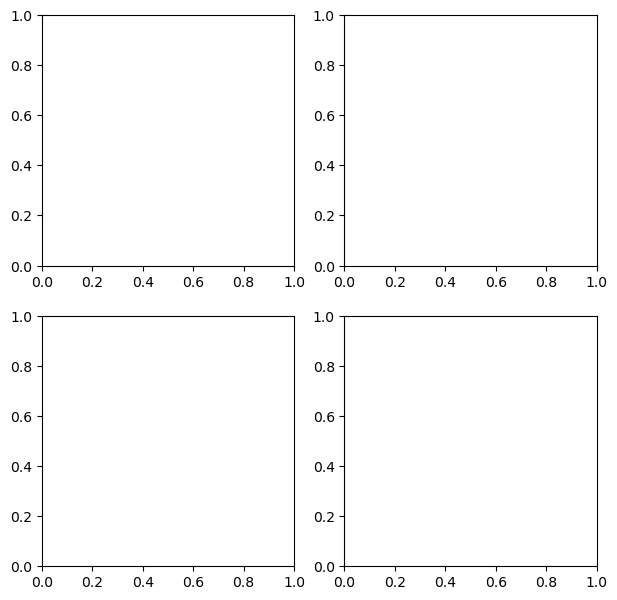

In [132]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np

# Dimensions du graphique
taille_graphe = 1.57 * 2.
espace_entre_graphes = .28
hauteur = taille_graphe * (2 + 1 * espace_entre_graphes)
largeur = taille_graphe * (2 + 1 * espace_entre_graphes)

fig = plt.figure(figsize=(largeur, hauteur))
graphe1 = fig.add_subplot(221)
graphe2 = fig.add_subplot(222)
graphe3 = fig.add_subplot(223)
graphe4 = fig.add_subplot(224)

dist_max = 10

# Paramètres pour les limites des graphes
xmax = np.max([np.max(traj[0]) for traj in val_x])
xmin = np.min([np.min(traj[0]) for traj in val_x])
ymax = np.max([np.max(traj[1]) for traj in val_x])
ymin = np.min([np.min(traj[1]) for traj in val_x])
xmoy, ymoy = (xmin + xmax) / 2, (ymin + ymax) / 2
dx, dy = (xmax - xmin) / 2, (ymax - ymin) / 2
beta = 1.2
XM, Xm = xmoy + dx * beta, xmoy - dx * beta
YM, Ym = ymoy + dy * beta, ymoy - dy * beta

# Tracé des trajectoires viables avec couleur en fonction de theta0
for k in range(nombre_essaie):
    if distance_satelisation_atteint[k]:
        # Trajectoire pour chaque graphe avec variation de couleur
        theta0 = valeur_theta0[k]
        couleur = plt.cm.hsv(theta0 / np.pi)  # couleur basée sur theta0
        
        # Trajet pour chaque graphe
        for graphe in [graphe1, graphe2, graphe3]:
            #graphe.plot(val_x[k][0], val_x[k][1], color=couleur, label=f'$\\theta_0 = {theta0:.2f}$ radians')
            graphe.plot(val_x[k][0], val_x[k][1], color=couleur)

# Ajouter les éléments supplémentaires sur chaque graphique
# Axes et orbites de la Terre et de la Lune
for graphe in [graphe1, graphe2, graphe3]:
    graphe.axhline(0, ls='--')
    graphe.axvline(0, ls='--')

# Cercle représentant la Terre et la Lune
for graphe in [graphe1, graphe2, graphe3]:
    graphe.add_patch(Circle((-alpha, 0), RT / D, edgecolor='black', fill=False, hatch='//', lw=2.5))
    graphe.add_patch(Circle((1 - alpha, 0), RL / D, edgecolor='black', fill=False, hatch='//', lw=2.5))
graphe3.add_patch(Circle((1-alpha,0),10*RL/D,edgecolor= 'black',fill=False,lw=2.5))
# Ajouter le câble entre la Lune et L2 dans graphe3
cable_x = [1 - alpha, L2[0]]  # Coordonnées x du câble
cable_y = [0, 0]  # Coordonnées y du câble (sur l'axe x)
graphe3.plot(cable_x, cable_y, 'b--', linewidth=2, label="Câble Lune-L2")

# Limites de chaque graphique pour visualisation
graphe1.set_xlim([Xm, XM])
graphe1.set_ylim([Ym, YM])
graphe3.set_xlim([1 - alpha - dist_max * rL, 1 - alpha + dist_max * rL])
graphe3.set_ylim([-dist_max * rL, dist_max * rL])
graphe2.set_xlim([-alpha - dist_max * rT, -alpha + dist_max * rT])
graphe2.set_ylim([-dist_max * rT, dist_max * rT])

# Ajout de texte pour la Terre et la Lune
graphe2.text(-alpha, 0, 'Terre', ha='center', va='center', bbox=dict(boxstyle="square", ec='red', fc='white', alpha=.8))
graphe3.text(1 - alpha, 0, 'Lune', ha='center', va='center', bbox=dict(boxstyle="square", ec='red', fc='white', alpha=.8))

# Légende et labels
for ax in [graphe1, graphe2, graphe3]:
    ax.set_xlabel('$X$ (unité : $D$)', fontsize=12)
    ax.set_ylabel('$Y$ (unité : $D$)', fontsize=12)
    ax.legend()

# Colorbar pour theta0
#sm = plt.cm.ScalarMappable(cmap="hsv", norm=plt.Normalize(vmin=0, vmax=np.pi))
#cbar = fig.colorbar(sm, ax=fig.axes, orientation="horizontal", pad=0.1, aspect=50, label=r"$\theta_0$ (radians)")
#cbar.set_ticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
#cbar.set_ticklabels([r"0", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"])

# Filtrer les valeurs de deltaV et theta0 où la condition distance_satelisation_atteint est True
theta0_valid = [valeur_theta0[i] for i in range(len(valeur_theta0)) if distance_satelisation_atteint[i]]
deltaV_valid = [deltaV[i] for i in range(len(deltaV)) if distance_satelisation_atteint[i]]

# Identifier l'indice du minimum de deltaV parmi les valeurs valides
min_index = np.argmin(deltaV_valid)
theta0_min = theta0_valid[min_index]
deltaV_min = deltaV_valid[min_index]

# Tracé de deltaV en fonction de theta0 sous forme de fonction dans graphe4
#fig, graphe4 = plt.subplots(figsize=(8, 6))
graphe4.plot(theta0_valid, deltaV_valid, marker='o', color='blue', linestyle='-', linewidth=2, markersize=5, label=r"$\Delta V$ vs. $\theta_0$")
graphe4.plot(theta0_min, deltaV_min, marker='o', color='red', markersize=8, label=r"Minimum $\Delta V$")

# Ajouter les labels et le titre
graphe4.set_xlabel(r"$\theta_0$ (radians)")
graphe4.set_ylabel(r"$\Delta V$ (m/s)")
graphe4.set_title(r"Variation de $\Delta V$ en fonction de $\theta_0$ avec Minimum en Rouge")

# Ajustement des ticks en radians pour theta
graphe4.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
graphe4.set_xticklabels([r"0", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"])

# Afficher la légende et le graphique
graphe4.legend()

traj_min = val_x[min_index]
# Dimensions pour les graphiques autour de la Terre et de la Lune
dist_max_terre = 10 * rT  # Distance max autour de la Terre
dist_max_lune = 10 * rL   # Distance max autour de la Lune

# Création de la figure avec trois sous-graphiques
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f"Trajectoire avec $\Delta V$ minimum pour $\\theta_0 = {theta0_min:.2f}$ radians")

# 1. Graphique centré sur la Terre
ax1.plot(traj_min[0], traj_min[1], color='green', label="Trajectoire pour $\Delta V$ min")
ax1.set_xlim([-alpha - dist_max * rT, -alpha + dist_max * rT])
ax1.set_ylim([-dist_max * rT, dist_max * rT])
ax1.set_title("Trajectoire autour de la Terre")
ax1.set_xlabel("$X$ (unité : $D$)")
ax1.set_ylabel("$Y$ (unité : $D$)")
ax1.add_patch(Circle((-alpha, 0), RT / D, edgecolor='black', fill=False, hatch='//', lw=2.5, label="Terre"))
ax1.legend()

# 2. Graphique centré sur la Lune
ax2.plot(traj_min[0], traj_min[1], color='green')
ax2.set_xlim([1 - alpha - dist_max * rL, 1 - alpha + dist_max * rL])
ax2.set_ylim([-dist_max * rL, dist_max * rL])
ax2.set_title("Trajectoire autour de la Lune")
ax2.set_xlabel("$X$ (unité : $D$)")
ax2.set_ylabel("$Y$ (unité : $D$)")
ax2.add_patch(Circle((1 - alpha, 0), RL / D, edgecolor='black', fill=False, hatch='//', lw=2.5, label="Lune"))
ax2.plot([L2[0]], [0], 'ro', label="Point $L_2$")
ax2.legend()

# 3. Graphique global
ax3.plot(traj_min[0], traj_min[1], color='green')
ax3.set_xlim([Xm,XM])
ax3.set_ylim([Ym,YM])
ax3.set_title("Trajectoire complète")
ax3.set_xlabel("$X$ (unité : $D$)")
ax3.set_ylabel("$Y$ (unité : $D$)")
ax3.add_patch(Circle((-alpha, 0), RT / D, edgecolor='black', fill=False, hatch='//', lw=2.5, label="Terre"))
ax3.add_patch(Circle((1 - alpha, 0), RL / D, edgecolor='black', fill=False, hatch='//', lw=2.5, label="Lune"))
ax3.plot([L2[0]], [0], 'ro', label="Point $L_2$")
ax3.legend()

# Appliquer l'échelle égale pour les trois graphiques
#for ax in [ax1, ax2, ax3]:
#    ax.axis('equal')



fig.tight_layout()
plt.show()


In [59]:
#orbite en 2 temps

# Événement : parallèle à l'axe T-L
def est_parr_a_TL_dans_le_sens_plus_ux(t, x):
    return x[3]
est_parr_a_TL_dans_le_sens_plus_ux.terminal = False
est_parr_a_TL_dans_le_sens_plus_ux.direction = -1

def est_parr_a_TL_dans_le_sens_moins_ux(t, x):
    return x[3]
est_parr_a_TL_dans_le_sens_moins_ux.terminal = False
est_parr_a_TL_dans_le_sens_moins_ux.direction = 1

nombre_essaie=1
TMAX=5*10^-1
# Variables pour stocker résultats
val_x=[]
val_t=[]
deltaV=[]
#distance_satelisation_atteint=[]

for k in range(nombre_essaie):
    theta0= - np.pi/4

    r0=rT*2
    r_perigee=1.2*rT
    v0= np.sqrt((1-alpha)/r0)
    
    x0,y0=-alpha+r0*np.cos(theta0),r0*np.sin(theta0)
    vx0,vy0=-v0*np.sin(theta0),v0*np.cos(theta0)

    # Variables pour stocker les résultats
    N = 1000                      # Nombre total de points souhaités
    point_utilise = 0             # Compteur de points déjà utilisés
    valeur_x = []
    valeur_t = []
    n = 0
    temps_event = []              # Liste pour stocker les temps où l'événement est détecté
    t_start = 0
    t_origine = np.linspace(0, TMAX, N)
    t_eval = np.linspace(0, TMAX, N)  # Discrétisation initiale de t_eval en N points

    delta_t = (TMAX - t_start) / (N - 1) #utile pour retrouver le n associé à un t

    # Conditions initiales
    CI = [x0, y0, vx0, vy0]

    # Boucle d'intégration avec ajustement de t_eval pour détecter plusieurs occurrences de l'événement
    while t_start < TMAX and point_utilise < N:
        # Calcul des points restants pour t_eval
        remaining_points = N - point_utilise
        t_eval = np.linspace(t_start, TMAX, remaining_points)
        deltaV.append(0)
        # Intégration avec solve_ivp
        traj3 = solve_ivp(rhs2, (t_start, TMAX), CI, method='RK45', t_eval=t_eval, rtol=1.49012e-12, atol=1.49012e-12, events=[est_parr_a_TL_dans_le_sens_plus_ux, est_parr_a_TL_dans_le_sens_moins_ux], dense_output=True)

        # Stocker les résultats partiels
        valeur_x.append(traj3.y)
        valeur_t.append(traj3.t)
        point_utilise += len(traj3.t)  # Mise à jour du compteur de points utilisés
        if traj3.t_events[0].size > 0:  # Si un événement est détecté
            # Récupérer l'état au moment de l'événement
            t_event = traj3.t_events[0][-1]
            state_event = traj3.sol(t_event)
            temps_event.append(t_event)

            # Appliquer la première impulsion pour réduire la vitesse
            r_event = np.linalg.norm(state_event[:2])  # Distance actuelle à la Terre
            v_event = np.linalg.norm(state_event[2:])  # Vitesse actuelle
            direction = state_event[2:] / v_event # Direction actuelle
            e= (r0-r_perigee)/(r0+r_perigee)
            v_new = np.sqrt(alpha * (1+e) / r_perigee)
            deltaV[k] += abs(v_new - v_event)  # Mise à jour du deltaV total
            state_event[2:] = [1,1]#v_new * direction  # Mettre à jour les composantes de vitesse
            # Continuer l'intégration après l'impulsion
            # Mise à jour des conditions initiales
            CI = state_event.ravel()
            t_start = t_event

            # Concaténer les résultats finaux
            valeur_x = np.hstack(valeur_x)
            valeur_t = np.hstack(valeur_t)

            # Stocker cet essai
            val_x.append(valeur_x)
            val_t.append(valeur_t)
            
            # Réinitialiser valeur_x et valeur_t pour n'inclure que la trajectoire circulaire
            valeur_x = []
            valeur_t = []

            # Nouvelle intégration pour trajectoire circulaire
            remaining_points = N - point_utilise
            t_eval = np.linspace(t_start, TMAX, remaining_points)
            traj2 = solve_ivp(rhs2, (t_start, TMAX), CI, method='DOP853',max_step = 1e-3, t_eval=t_eval, rtol=1.49012e-12, atol=1.49012e-12, events=[distance_satelisation,est_dans_la_lune] , dense_output=True)

            # Stocker uniquement les résultats de la trajectoire circulaire
            valeur_x.append(traj2.y)
            valeur_t.append(traj2.t)
            break

        # Deuxième impulsion pour accélérer au périgée
        if traj3.t_events[1].size > 0:  # Si un deuxième événement est détecté
            t_event = traj3.t_events[1][-1]
            state_event = traj3.sol(t_event)
            temps_event.append(t_event)

            # Appliquer la deuxième impulsion pour accélérer au périgée
            r_event = np.linalg.norm(state_event[:2])  # Distance actuelle à la Terre
            v_event = np.linalg.norm(state_event[2:])  # Vitesse actuelle
            direction = state_event[2:] / v_event # Direction actuelle
            v_new = v1T*np.sqrt(rT/r0)*np.sqrt(2)*.9887  
            deltaV[k] += abs(v_new - v_event)  # Mise à jour du deltaV total
            state_event[2:] = v_new * direction  # Mettre à jour les composantes de vitesse

            # Continuer l'intégration après la deuxième impulsion
            # Mise à jour des conditions initiales
            CI = state_event.ravel()
            t_start = t_event

            # Concaténer les résultats finaux
            valeur_x = np.hstack(valeur_x)
            valeur_t = np.hstack(valeur_t)

            # Stocker cet essai
            val_x.append(valeur_x)
            val_t.append(valeur_t)

        
  
        









Text(0.9878491707646521, 0, 'Lune')

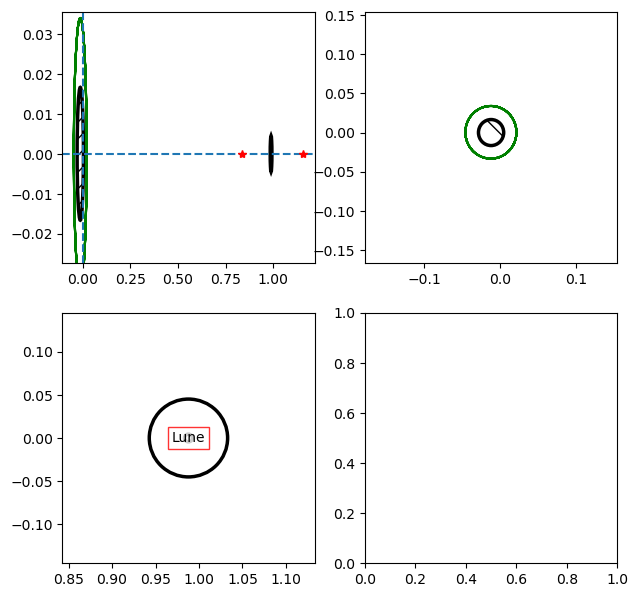

In [217]:
taille_graphe=1.57*2.
espace_entre_graphes=.28
hauteur=taille_graphe*(2+1*espace_entre_graphes)
largeur=taille_graphe*(2+1*espace_entre_graphes)

fig=figure(figsize=(largeur,hauteur))
graphe1=fig.add_subplot(221)
graphe2=fig.add_subplot(222)
graphe3=fig.add_subplot(223)#,projection='polar')
graphe4=fig.add_subplot(224)

dist_max=10


xmax=np.max(val_x[0][0]);xmin=np.min(traj[:,0]);xmoy=(xmin+xmax)/2;dx=(xmax-xmin)/2
ymax=np.max(val_x[0][1]);ymin=np.min(traj[:,1]);ymoy=(ymin+ymax)/2;dy=(ymax-ymin)/2
beta=1.2
XM=xmoy+dx*beta;Xm=xmoy-dx*beta
Ym=ymoy-dy*beta;YM=ymoy+dy*beta

graphe3.plot(val_x[0][0],val_x[0][1],'g-',label='$v0=${:.4f}'.format(v0))
graphe2.plot(val_x[0][0],val_x[0][1],'g-',label='$v0=${:.4f}'.format(v0))
graphe1.plot(val_x[0][0],val_x[0][1],'g-',label='$v0=${:.4f}'.format(v0))


graphe1.axhline(0,ls='--');graphe1.axvline(0,ls='--')
graphe1.set_ylim([ymin-.05*dy,ymax+.05*dy])

graphe1.add_patch(Circle((-alpha,0),RT/D,edgecolor= 'black',fill=False,hatch='//',lw=2.5))
graphe1.add_patch(Circle((1-alpha,0),RL/D,edgecolor= 'black',fill=False,hatch='//',lw=2.5))
graphe1.plot([L1],[0],'r*')
graphe1.plot([L2],[0],'r*')



graphe3.set_xlim([(1-alpha-dist_max*rL)-0.1,(1-alpha+dist_max*rL)+0.1])
graphe3.set_ylim([(-dist_max*rL)-0.1,(dist_max*rL)+0.1])
graphe3.add_patch(Circle((1-alpha,0),RL/D,edgecolor= 'black',fill=False,hatch='//',lw=2.5))
graphe3.add_patch(Circle((1-alpha,0),10*RL/D,edgecolor= 'black',fill=False,lw=2.5))






graphe2.set_xlim([-alpha-dist_max*rT,-alpha+dist_max*rT])
graphe2.set_ylim([-dist_max*rT,-alpha+dist_max*rT])
graphe2.add_patch(Circle((-alpha,0),RT/D,edgecolor= 'black',fill=False,hatch='\\',lw=2.5))



#graphe2.text(-alpha,0,'Terre',ha='center',va='center',bbox=dict(boxstyle="square",ec='red',fc='white',alpha=.8))
graphe3.text(1-alpha,0,'Lune',ha='center',va='center',bbox=dict(boxstyle="square",ec='red',fc='white',alpha=.8))

(-0.5, 10.0)

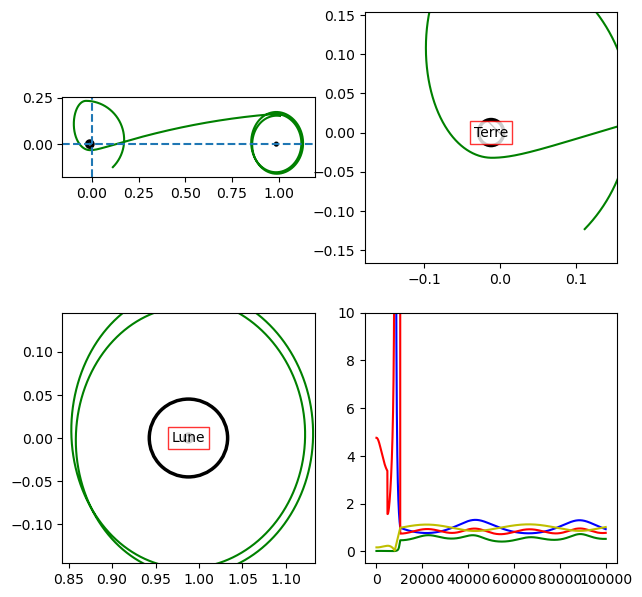

In [281]:






# Événement : parallèle à l'axe T-L
def est_parr_a_TL_dans_le_sens_plus_ux(t, x):
    return x[3]
est_parr_a_TL_dans_le_sens_plus_ux.terminal = False
est_parr_a_TL_dans_le_sens_plus_ux.direction = -1

def est_parr_a_TL_dans_le_sens_moins_ux(t, x):
    return x[3]
est_parr_a_TL_dans_le_sens_moins_ux.terminal = False
est_parr_a_TL_dans_le_sens_moins_ux.direction = 1

TMAX=5
valeur_x= []
valeur_t= []
deltaV=[]

theta0= - np.pi/4

r0=rT*10.5
r_perigee=1.75*rT
v0= np.sqrt((1-alpha)/r0)
e= (r0-r_perigee)/(r0+r_perigee)
    
x0,y0=-alpha+r0*np.cos(theta0),r0*np.sin(theta0)
vx0,vy0=-v0*np.sin(theta0),v0*np.cos(theta0)

# Variables pour stocker les résultats
N = 100000                   # Nombre total de points souhaités
point_utilise = 0             # Compteur de points déjà utilisés
n = 0
temps_event = []              # Liste pour stocker les temps où l'événement est détecté
t_start=0
t_origine = np.linspace(0, TMAX, N)
t_eval = np.linspace(0, TMAX, N)  # Discrétisation initiale de t_eval en N points

delta_t = (TMAX - t_start) / (N - 1) #utile pour retrouver le n associé à un t

# Conditions initiales
CI = [x0, y0, vx0, vy0]

traj3 = solve_ivp(rhs2, 
                  (t_start, TMAX), 
                  CI, 
                  method='RK45', 
                  t_eval=t_eval, 
                  rtol=1.49012e-12, 
                  atol=1.49012e-12, 
                  events=[est_parr_a_TL_dans_le_sens_plus_ux, est_parr_a_TL_dans_le_sens_moins_ux],
                  dense_output=True)

valeur_x.append(traj3.y)
valeur_t.append(traj3.t)

if traj3.t_events[0].size>0:
    # Stocker la trajectoire avant l'ajustement circulaire
    trajectoire_initiale_x = np.hstack(valeur_x)  # Sauvegarde la première partie
    trajectoire_initiale_t = np.hstack(valeur_t)
    
    #création du nouveau domaine temporel
    t_event = traj3.t_events[0][0]
    n=round(t_event/delta_t)
    t_eval=np.linspace(t_event,TMAX,N-n)
    
    #création des nouvelles CI
    etat_event = traj3.sol(t_event)
    v_event=etat_event[2:]
    #v_new = (2+(1-alpha)/(r0*(1+r0/r_perigee)))**1/2
    #v_new = (2+(1-alpha)/(r_perigee*(1+r_perigee/r0)))**1/2 #np.linalg.norm(v_event)*((2/(1+r0/r_perigee))**1/2)
    delta_v=-np.linalg.norm(v_event)*(1-np.sqrt(2/(1+r0/r_perigee)))
    direction = v_event/np.linalg.norm(v_event)
    etat_event[2:]= v_event*(1-np.sqrt(2/(1+r0/r_perigee)))
    CI = etat_event
    
    #nouvelle intégration avec les nouvelles CI et domaine temp
    traj3=solve_ivp(rhs2, 
                      (t_event, TMAX), 
                      CI, 
                      method='RK45', 
                      t_eval=t_eval, 
                      rtol=1.49012e-12, 
                      atol=1.49012e-12, 
                      events=[est_parr_a_TL_dans_le_sens_plus_ux, est_parr_a_TL_dans_le_sens_moins_ux],
                      dense_output=True)
   
    
    #concaténation des résultats 
    valeur_x = []
    valeur_t = []
    # Stocker uniquement les résultats de la trajectoire circulaire
    valeur_x.append(traj3.y)
    valeur_t.append(traj3.t)
    valeur_x = np.hstack(valeur_x)
    valeur_t = np.hstack(valeur_t)
    
    valeur_x = np.hstack([trajectoire_initiale_x[:,:n], valeur_x])
    valeur_t = np.hstack([trajectoire_initiale_t[:n], valeur_t])
    
if traj3.t_events[1].size>0:
    # Stocker la trajectoire avant l'ajustement circulaire
    trajectoire_initiale_x = np.copy(valeur_x)  # Sauvegarde la première partie
    trajectoire_initiale_t = np.copy(valeur_t)
     
    #création du nouveau domaine temporel
    t_event = traj3.t_events[1][0]
    n=round(t_event/delta_t)
    t_eval=np.linspace(t_event,TMAX,N-n)
     
    #création des nouvelles CI
    etat_event = traj3.sol(t_event)
    v_event=etat_event[2:]
    direction = v_event/np.linalg.norm(v_event)
    v_lib=np.sqrt(2*(1-alpha)/r_perigee + np.linalg.norm(v_event)**2)
    etat_event[2:]= direction*v_lib
    CI = etat_event
     
    #nouvelle intégration avec les nouvelles CI et domaine temp
    traj3=solve_ivp(rhs2, 
                      (t_event, TMAX), 
                       CI, 
                       method='RK45', 
                       t_eval=t_eval, 
                       rtol=1.49012e-12, 
                       atol=1.49012e-12, 
                       events=[est_parr_a_TL_dans_le_sens_plus_ux, est_parr_a_TL_dans_le_sens_moins_ux],
                       dense_output=True)
    
     
    #concaténation des résultats 
    valeur_x = []
    valeur_t = []
    # Stocker uniquement les résultats de la trajectoire circulaire
    valeur_x.append(traj3.y)
    valeur_t.append(traj3.t)
    valeur_x = np.hstack(valeur_x)
    valeur_t = np.hstack(valeur_t)
     
    valeur_x = np.hstack([trajectoire_initiale_x[:,:n], valeur_x])
    valeur_t = np.hstack([trajectoire_initiale_t[:n], valeur_t]) 
    
if True:
    # Stocker la trajectoire avant l'ajustement circulaire
    trajectoire_initiale_x = np.copy(valeur_x)  # Sauvegarde la première partie
    trajectoire_initiale_t = np.copy(valeur_t)
    
    distance_lune=((-valeur_x[0]+1-alpha)**2 + valeur_x[1]**2)**0.5
    dMin = np.min(distance_lune)
    n = np.argmin(distance_lune)
    t_event= valeur_t[n]
    t_eval=np.linspace(t_event,TMAX,N-n)
    
    v_circ = np.sqrt(alpha / dMin)  # Vitesse pour une orbite circulaire à dMin   
    #création des nouvelles CI
    etat_event = traj3.sol(t_event)
    v_event=etat_event[2:]
    x_Min = etat_event[0]
    y_Min = etat_event[1]
    
    #on crée un vecteur directeur dirigée dans le bon sens et tangeant au cercle de rayon dMin
    LM = [x_Min-1+alpha ,y_Min]
    LM_perpandiculaire = [-y_Min,x_Min-1+alpha]
    if np.dot(LM_perpandiculaire,v_event)<0:
        LM_perpandiculaire = [y_Min,-x_Min+1-alpha]
        
    direction = LM_perpandiculaire/np.linalg.norm(LM_perpandiculaire)
    
    coeff_correcteur = r_perigee/rT * 0.552 + 0.390
    etat_event[2:]= direction*v_circ*coeff_correcteur
    CI = etat_event
    
    #nouvelle intégration avec les nouvelles CI et domaine temp
    traj3=solve_ivp(rhs2, 
                      (t_event, TMAX), 
                       CI, 
                       method='RK45', 
                       t_eval=t_eval, 
                       rtol=1.49012e-12, 
                       atol=1.49012e-12, 
                       events=[est_parr_a_TL_dans_le_sens_plus_ux, est_parr_a_TL_dans_le_sens_moins_ux],
                       dense_output=True)
    #concaténation des résultats 
    valeur_x = []
    valeur_t = []
    # Stocker uniquement les résultats de la trajectoire circulaire
    valeur_x.append(traj3.y)
    valeur_t.append(traj3.t)
    valeur_x = np.hstack(valeur_x)
    valeur_t = np.hstack(valeur_t)
     
    valeur_x = np.hstack([trajectoire_initiale_x[:,:n], valeur_x])
    valeur_t = np.hstack([trajectoire_initiale_t[:n], valeur_t]) 
    
    
#calcul des forces le long du trajet : 
val_G1x=-(1-alpha)*(valeur_x[0]+alpha)/((valeur_x[0]+alpha)**2+valeur_x[1]**2)**(3/2)
val_G1y=-(1-alpha)*valeur_x[1]/((valeur_x[0]+alpha)**2+valeur_x[1]**2)**(3/2)
val_G2x=-alpha*(valeur_x[0]-1+alpha)/((valeur_x[0]-1+alpha)**2+valeur_x[1]**2)**(3/2)
val_G2y=-alpha*valeur_x[1]/((valeur_x[0]-1+alpha)**2+valeur_x[1]**2)**(3/2)
val_Ficx=2*valeur_x[3]
val_Ficy=-2*valeur_x[2]
val_Fiex=valeur_x[0]
val_Fiey=valeur_x[1] 

val_G1= np.sqrt(val_G1x**2 + val_G1y**2)
val_G2= np.sqrt(val_G2x**2 + val_G2y**2)
val_Fic= np.sqrt(val_Ficx**2 + val_Ficy**2)
val_Fie= np.sqrt(val_Fiex**2 + val_Fiey**2)

#calcul de l'énergie le long du trajet
Ep1=-(1-alpha)/((valeur_x[0]+alpha)**2+valeur_x[1]**2)**(1/2)
Ep2=-alpha/((valeur_x[0]-1+alpha)**2+valeur_x[1]**2)**(1/2)
Ep3=-.5*(valeur_x[0]**2+valeur_x[1]**2)

Ep= Ep1 +Ep2+ Ep3
Ec=1/2 * D * m /(Cste_G*(MT+ML)) * np.sqrt(valeur_x[2]**2 + valeur_x[3]**2)

Em= Ep + Ec



taille_graphe=1.57*2.
espace_entre_graphes=.28
hauteur=taille_graphe*(2+1*espace_entre_graphes)
largeur=taille_graphe*(2+1*espace_entre_graphes)

fig=figure(figsize=(largeur,hauteur))
graphe1=fig.add_subplot(221)
graphe2=fig.add_subplot(222)
graphe3=fig.add_subplot(223)#,projection='polar')
graphe4=fig.add_subplot(224)

dist_max=10


xmax=np.max(valeur_x[:,0]);xmin=np.min(valeur_x[:,0]);xmoy=(xmin+xmax)/2;dx=(xmax-xmin)/2
ymax=np.max(valeur_x[:,1]);ymin=np.min(valeur_x[:,1]);ymoy=(ymin+ymax)/2;dy=(ymax-ymin)/2
beta=1.2
XM=xmoy+dx*beta;Xm=xmoy-dx*beta
Ym=ymoy-dy*beta;YM=ymoy+dy*beta

graphe3.plot(valeur_x[0,:],valeur_x[1,:],'g-',label='$v0=${:.4f}'.format(v0))
graphe2.plot(valeur_x[0,:],valeur_x[1,:],'g-',label='$v0=${:.4f}'.format(v0))
graphe1.plot(valeur_x[0,:],valeur_x[1,:],'g-',label='$v0=${:.4f}'.format(v0))


graphe1.axhline(0,ls='--');graphe1.axvline(0,ls='--')

#graphe1.set_xlim([-0.10,0.10])
#graphe1.set_ylim([-1,1])
#graphe1.set_ylim([ymin-.05*dy,ymax+.05*dy])

graphe1.add_patch(Circle((-alpha,0),RT/D,edgecolor= 'black',fill=False,hatch='//',lw=2.5))
graphe1.add_patch(Circle((1-alpha,0),RL/D,edgecolor= 'black',fill=False,hatch='//',lw=2.5))




graphe3.set_xlim([(1-alpha-dist_max*rL)-0.1,(1-alpha+dist_max*rL)+0.1])
graphe3.set_ylim([(-dist_max*rL)-0.1,(dist_max*rL)+0.1])
graphe3.add_patch(Circle((1-alpha,0),RL/D,edgecolor= 'black',fill=False,hatch='//',lw=2.5))
graphe3.add_patch(Circle((1-alpha,0),10*RL/D,edgecolor= 'black',fill=False,lw=2.5))






graphe2.set_xlim([-alpha-dist_max*rT,-alpha+dist_max*rT])
graphe2.set_ylim([-dist_max*rT,-alpha+dist_max*rT])
graphe2.add_patch(Circle((-alpha,0),RT/D,edgecolor= 'black',fill=False,hatch='\\',lw=2.5))



graphe2.text(-alpha,0,'Terre',ha='center',va='center',bbox=dict(boxstyle="square",ec='red',fc='white',alpha=.8))
graphe3.text(1-alpha,0,'Lune',ha='center',va='center',bbox=dict(boxstyle="square",ec='red',fc='white',alpha=.8))

graphe1.set_aspect('equal', adjustable='box')


graphe4.plot(val_G1,'b-')
graphe4.plot(val_G2,'g-')
graphe4.plot(val_Fic,'r-')
graphe4.plot(val_Fie,'y-')
graphe4.set_ylim([-0.5,10])
